In [1]:
import pymc as pm, polars as pl, arviz as az
import numpy as np
import matplotlib.pyplot as plt

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [22]:
pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Primates301.csv", separator=";")

name,genus,species,subspecies,spp_id,genus_id,social_learning,research_effort,brain,body,group_size,gestation,weaning,longevity,sex_maturity,maternal_investment
str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str
"""Allenopithecus_nigroviridis""","""Allenopithecus""","""nigroviridis""","""NA""",1,1,"""0""","""6""","""58.02""","""4655""","""40""","""NA""","""106.15""","""276""","""NA""","""NA"""
"""Allocebus_trichotis""","""Allocebus""","""trichotis""","""NA""",2,2,"""0""","""6""","""NA""","""78.09""","""1""","""NA""","""NA""","""NA""","""NA""","""NA"""
"""Alouatta_belzebul""","""Alouatta""","""belzebul""","""NA""",3,3,"""0""","""15""","""52.84""","""6395""","""7.4""","""NA""","""NA""","""NA""","""NA""","""NA"""
"""Alouatta_caraya""","""Alouatta""","""caraya""","""NA""",4,3,"""0""","""45""","""52.63""","""5383""","""8.9""","""185.92""","""323.16""","""243.6""","""1276.72""","""509.08"""
"""Alouatta_guariba""","""Alouatta""","""guariba""","""NA""",5,3,"""0""","""37""","""51.7""","""5175""","""7.4""","""NA""","""NA""","""NA""","""NA""","""NA"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Trachypithecus_pileatus""","""Trachypithecus""","""pileatus""","""NA""",297,67,"""0""","""5""","""103.64""","""11794""","""8.5""","""NA""","""NA""","""NA""","""NA""","""NA"""
"""Trachypithecus_poliocephalus""","""Trachypithecus""","""poliocephalus""","""NA""",298,67,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""
"""Trachypithecus_vetulus""","""Trachypithecus""","""vetulus""","""NA""",299,67,"""0""","""2""","""61.29""","""6237""","""8.35""","""204.72""","""245.78""","""276""","""1113.7""","""450.5"""


In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Primates301.csv", separator=";").filter((pl.col("brain") != "NA") & (pl.col("social_learning") != "NA")).with_columns(
    log_brain=pl.col("brain").cast(pl.Float32).log(),
    social_learning=pl.col("social_learning").cast(pl.Float32),
).select("name", "genus", "species", "brain", "log_brain", "social_learning")

In [19]:
with pm.Model() as basic_model:
    # data
    log_brain = pm.Data("log_brain", df["log_brain"].to_numpy())

    # priors
    alpha = pm.Normal("alpha", mu=0, sigma=0.2)
    beta_log_brain = pm.Normal("beta_log_brain", mu=0, sigma=0.3)

    # model definition
    log_lambda = pm.Deterministic("log_lambda", alpha + beta_log_brain*log_brain)
    expected_count = pm.Deterministic("expected_count", pm.math.exp(log_lambda))

    social_learning = pm.Poisson("social_learning", expected_count, observed=df["social_learning"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["social_learning", "expected_count"])

    # sample
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta_log_brain, social_learning]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_brain]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [social_learning]


Output()

Output()

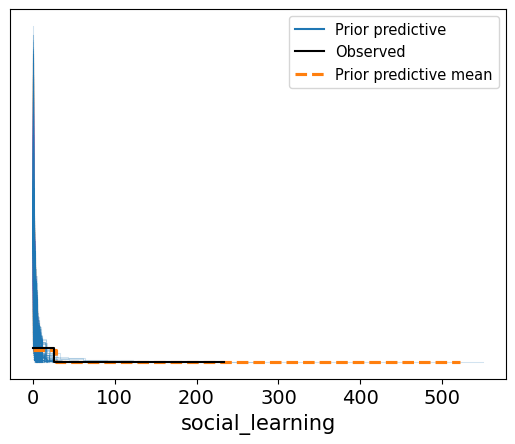

In [20]:
# prior predictive check
ax = az.plot_ppc(prior_predictive, group="prior", observed=True)

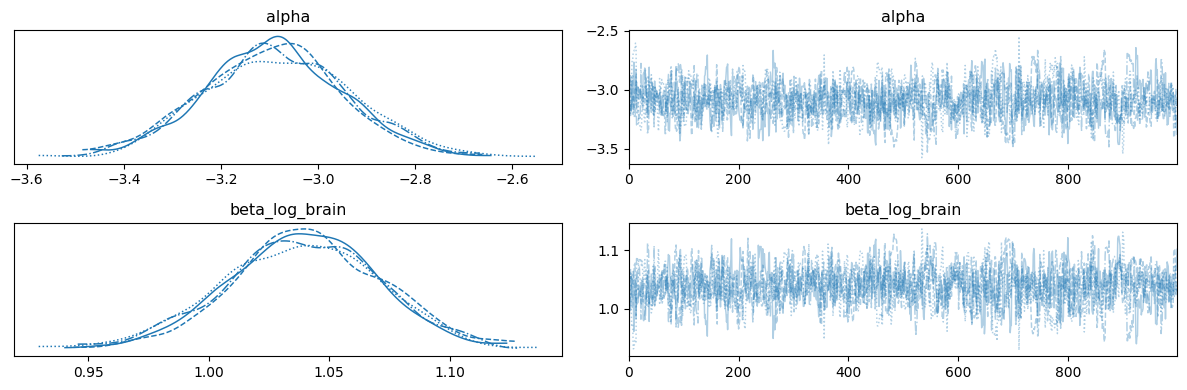

In [21]:
plot_trace(posterior, var_names=["alpha", "beta_log_brain"])